<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/18_NeuroFHIR_SAFE_Integrated_WISH_Results_and_Figures_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 18 — NeuroFHIR-SAFE
## Corrected Integrated WISH Results + GO/NO-GO



The FHIR result is reported with the correct boundary:
**WISH-specific trace-derived state/provenance conformance + previously executed NeuroFHIR-QC server write-back/read-back evidence.**

In [1]:
# Cell 1 — Mount / load
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json, pandas as pd, datetime, textwrap
import matplotlib.pyplot as plt

ROOT = Path("/content/drive/MyDrive/neurofhir-qc/wish_extension/neurofhir_safe")
FORMAL = ROOT / "artifacts" / "formal"
IMPL = ROOT / "artifacts" / "implementation"
EXPERT = ROOT / "artifacts" / "expert_walkthrough"
FINAL = ROOT / "artifacts" / "integrated_wish"
FINAL.mkdir(parents=True, exist_ok=True)

formal = json.loads((FORMAL / "formal_results.json").read_text())
impl = json.loads((IMPL / "implementation_summary.json").read_text())

expert_path = EXPERT / "expert_walkthrough_summary.json"
expert = json.loads(expert_path.read_text()) if expert_path.exists() else None

Mounted at /content/drive


In [2]:
# Cell 2 — Load result tables
mutation_df = pd.read_csv(FORMAL / "mutation_results.csv")
runtime_df = pd.read_csv(IMPL / "runtime_trace_audit.csv")
fhir_df = pd.read_csv(IMPL / "fhir_safety_audit.csv")

display(mutation_df)
display(runtime_df)
display(fhir_df.head(40))

,mutant,expected_property,observed_violation,detected,states_generated,distinct_states,log
0,M1_early_ai,P1,P1,True,26,26,/content/drive/MyDrive/neurofhir-qc/wish_exten...
1,M2_hide_uncertainty,P2,P2,True,74,74,/content/drive/MyDrive/neurofhir-qc/wish_exten...
2,M3_low_qc_final,P3,P3,True,157,155,/content/drive/MyDrive/neurofhir-qc/wish_exten...
3,M4_unack_conflict,P4,P4,True,193,189,/content/drive/MyDrive/neurofhir-qc/wish_exten...
4,M5_no_model_identity,P5,P5,True,171,169,/content/drive/MyDrive/neurofhir-qc/wish_exten...
5,M6_no_provenance_reject,P6,P6,True,122,122,/content/drive/MyDrive/neurofhir-qc/wish_exten...
6,M7_ai_autofinal,P7,P7,True,98,98,/content/drive/MyDrive/neurofhir-qc/wish_exten...
7,M8_final_escalation,P9,P9,True,121,121,/content/drive/MyDrive/neurofhir-qc/wish_exten...
8,M9_task_mismatch,P10,P10,True,123,123,/content/drive/MyDrive/neurofhir-qc/wish_exten...


,participant_id,scenario_id,condition,initial_index,ai_exposed_index,passport_index,final_index,ai_visible_before_initial_judgment,condition_ordering_ok,provenance_before_final,final_after_initial,final_action
0,P001,S01,evidence-first,136,138,140,143,False,True,True,True,Accept AI
1,P001,S02,ai-first,5,3,8,11,True,True,True,True,Accept AI
2,P001,S03,ai-first,17,15,20,23,True,True,True,True,Accept AI
3,P001,S04,evidence-first,76,78,80,83,False,True,True,True,Accept AI
4,P001,S05,evidence-first,64,66,68,71,False,True,True,True,Accept AI
5,P001,S06,ai-first,53,51,56,59,True,True,True,True,Accept AI
6,P001,S07,ai-first,41,39,44,47,True,True,True,True,Accept AI
7,P001,S08,evidence-first,28,30,32,35,False,True,True,True,Accept AI
8,P001,S09,evidence-first,112,114,116,119,False,True,True,True,Accept AI
9,P001,S10,ai-first,89,87,92,95,True,True,True,True,Accept AI


,participant_id,scenario_id,condition,final_action,check,passed,bundle_path
0,P001,S01,evidence-first,Accept AI,imaging_context_present,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
1,P001,S01,evidence-first,Accept AI,model_identity_present,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
2,P001,S01,evidence-first,Accept AI,observation_report_status_agree,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
3,P001,S01,evidence-first,Accept AI,result_status_matches_final_action,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
4,P001,S01,evidence-first,Accept AI,task_status_matches_final_action,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
5,P001,S01,evidence-first,Accept AI,provenance_targets_terminal_objects,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
6,P001,S01,evidence-first,Accept AI,provenance_preserves_source_and_model,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
7,P001,S01,evidence-first,Accept AI,escalation_nonfinal,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
8,P001,S01,evidence-first,Accept AI,rejection_preserved,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...
9,P001,S02,ai-first,Accept AI,imaging_context_present,True,/content/drive/MyDrive/neurofhir-qc/wish_exten...


In [3]:
# Cell 3 — Gates
formal_ok = (
    formal["evidence_first"]["violated_property"] is None
    and formal["ai_first"]["violated_property"] == "P1"
    and formal["mutation_detection"]["detected"]
        == formal["mutation_detection"]["total"]
)

runtime = impl["runtime"]
runtime_ok = (
    runtime["evidence_first_traces"] > 0
    and runtime["evidence_first_order_conformance_rate"] == 1.0
    and runtime[
        "ai_first_structural_exposure_confirmation_rate"
    ] == 1.0
    and runtime["provenance_before_final_rate"] == 1.0
)

fhir = impl["fhir"]
fhir_ok = (
    fhir["wish_specific_bundles"] > 0
    and fhir["assertions"] > 0
    and fhir["pass_rate"] == 1.0
)

expert_ok = (
    expert is not None
    and expert.get("reviewer_count",0) in [1,2]
    and expert.get("completed_case_reviews",0) >= 4
)

gate_df = pd.DataFrame([
    ["Formal P1–P10 + AI-First counterexample + M1–M9", formal_ok, "Required"],
    ["Runtime Evidence-First / AI-First trace conformance", runtime_ok, "Required"],
    ["WISH-specific FHIR state/provenance conformance", fhir_ok, "Required"],
    ["1–2 expert formative walkthroughs", expert_ok, "Optional strengthening"],
], columns=["component","passed","role"])

display(gate_df)
gate_df.to_csv(FINAL / "go_no_go_gate.csv", index=False)

,component,passed,role
0,Formal P1–P10 + AI-First counterexample + M1–M9,True,Required
1,Runtime Evidence-First / AI-First trace confor...,True,Required
2,WISH-specific FHIR state/provenance conformance,True,Required
3,1–2 expert formative walkthroughs,False,Optional strengthening


In [4]:
# Cell 4 — Results language
detected = formal["mutation_detection"]["detected"]
total = formal["mutation_detection"]["total"]

expert_sentence = (
    f"A formative expert walkthrough included "
    f"{expert['reviewer_count']} expert reviewer(s) across "
    f"{expert['completed_case_reviews']} completed case reviews. "
    "These observations were treated as face-validity feedback only."
    if expert_ok else
    "No expert walkthrough is included in the primary result set; "
    "human evaluation remains an optional formative add-on."
)

status = (
    "STRONGEST CORE COMPLETE"
    if formal_ok and runtime_ok and fhir_ok
    else "CORE INCOMPLETE"
)

text = f"""
# NeuroFHIR-SAFE Integrated Result

**Status: {status}**

The Evidence-First finite workflow satisfied P1–P10 over the explored
finite model, while the controlled AI-First comparator generated the
pre-specified P1 counterexample. The verification pipeline detected
**{detected}/{total}** deliberate safety regressions.

Across the deterministic P001/P002 engineering traces, Evidence-First
ordering conformance was **{runtime['evidence_first_order_conformance_rate']:.0%}**,
AI-First pre-judgment exposure was confirmed in
**{runtime['ai_first_structural_exposure_confirmation_rate']:.0%}** of comparator
traces, and provenance inspection preceded final disposition in
**{runtime['provenance_before_final_rate']:.0%}** of case traces.

The WISH-specific trace-derived FHIR audit passed
**{fhir['assertions']}/{fhir['assertions']}** state/provenance assertions
across **{fhir['wish_specific_bundles']}** persisted audit bundles.
Separately, the underlying NeuroFHIR-QC pipeline had previously demonstrated
server validation/write-back/read-back of its canonical FHIR evidence
artifacts; that historical interoperability result is supporting baseline
evidence rather than a new 12-case WISH server result.

{expert_sentence}

## Claim boundary
These results support a pre-deployment interaction-safety,
implementation-trace-conformance, and FHIR state/provenance-conformance
claim. They do not establish improved clinician accuracy, reduced real-world
anchoring, improved patient outcomes, or clinical safety.
"""

summary_path = FINAL / "integrated_results_summary.md"
summary_path.write_text(textwrap.dedent(text).strip()+"\n", encoding="utf-8")
print(text)


# NeuroFHIR-SAFE Integrated Result

**Status: STRONGEST CORE COMPLETE**

The Evidence-First finite workflow satisfied P1–P10 over the explored
finite model, while the controlled AI-First comparator generated the
pre-specified P1 counterexample. The verification pipeline detected
**9/9** deliberate safety regressions.

Across the deterministic P001/P002 engineering traces, Evidence-First
ordering conformance was **100%**,
AI-First pre-judgment exposure was confirmed in
**100%** of comparator
traces, and provenance inspection preceded final disposition in
**100%** of case traces.

The WISH-specific trace-derived FHIR audit passed
**216/216** state/provenance assertions
across **24** persisted audit bundles.
Separately, the underlying NeuroFHIR-QC pipeline had previously demonstrated
server validation/write-back/read-back of its canonical FHIR evidence
artifacts; that historical interoperability result is supporting baseline
evidence rather than a new 12-case WISH server result.

No expe

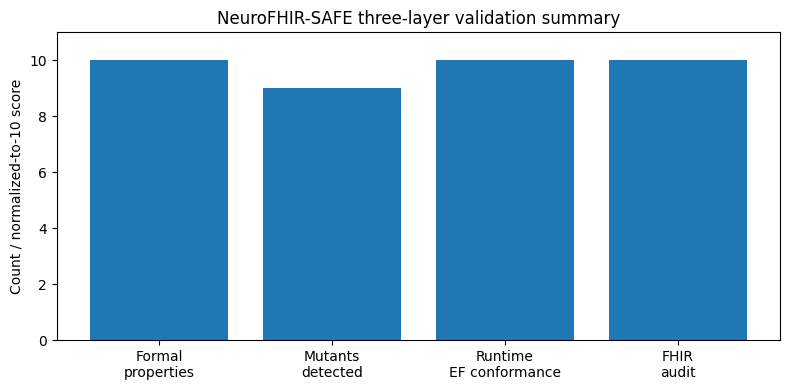

/content/drive/MyDrive/neurofhir-qc/wish_extension/neurofhir_safe/artifacts/integrated_wish/figure_core_validation_summary.png


In [5]:
# Cell 5 — Figure: core evidence layers
labels = ["Formal\nproperties", "Mutants\ndetected", "Runtime\nEF conformance", "FHIR\naudit"]
values = [
    10,
    detected,
    runtime["evidence_first_order_conformance_rate"] * 10,
    fhir["pass_rate"] * 10,
]

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(labels, values)
ax.set_ylim(0,11)
ax.set_ylabel("Count / normalized-to-10 score")
ax.set_title("NeuroFHIR-SAFE three-layer validation summary")
fig.tight_layout()

out = FINAL / "figure_core_validation_summary.png"
fig.savefig(out, dpi=180)
plt.show()
print(out)

In [6]:
# Cell 6 — WISH-ready outline
outline = f"""
# Can Human-First Be Enforced?
## Formal Verification of an Evidence-First Clinical AI Review Workflow

### Problem
Human-centered AI research suggests that premature AI exposure can shape
deference, but a design recommendation does not ensure that a real workflow
preserves the intended ordering across error states and software changes.

### Objective
Translate Human-First design principles into explicit interaction-safety
properties, verify them over a finite workflow model, and test whether the
running NeuroFHIR-Review implementation and its FHIR audit representation
conform.

### Methods
- P1–P10 safety properties.
- TLA+/TLC finite-state verification.
- Controlled AI-First comparator.
- M1–M9 deliberate safeguard mutations.
- P001/P002 deterministic 12-case engineering traces.
- Explicit `event_type` runtime conformance checks.
- WISH-specific trace-derived FHIR Task/Device/Provenance audit.
- Previously executed NeuroFHIR-QC HAPI validation/write-back/read-back
  reported as supporting interoperability evidence.
- Optional 1–2 expert formative walkthroughs.

### Results
- Formal core: {"PASS" if formal_ok else "INCOMPLETE"}.
- AI-First P1 counterexample: {"DETECTED" if formal['ai_first']['violated_property']=='P1' else "NOT DETECTED"}.
- Mutation detection: {detected}/{total}.
- Evidence-First runtime ordering: {runtime['evidence_first_order_conformance_rate']:.0%}.
- AI-First pre-judgment exposure confirmation: {runtime['ai_first_structural_exposure_confirmation_rate']:.0%}.
- WISH-specific FHIR audit: {fhir['pass_rate']:.0%}.
- Expert formative layer: {"included" if expert_ok else "not included"}.

### Contribution
A reproducible pre-deployment method for converting Human-First interaction
evidence into machine-testable workflow constraints and checking that those
constraints survive formal modeling, executable workflow traces, and
FHIR-native audit representation.

### Claim boundary
No claim of improved diagnostic accuracy, reduced real-world anchoring,
clinical effectiveness, or proven clinical safety.
"""

path = FINAL / "WISH_1to2_page_results_outline.md"
path.write_text(textwrap.dedent(outline).strip()+"\n", encoding="utf-8")
print(path)

/content/drive/MyDrive/neurofhir-qc/wish_extension/neurofhir_safe/artifacts/integrated_wish/WISH_1to2_page_results_outline.md


In [7]:
# Cell 7 — Final decision
print("="*84)
print("NEUROFHIR-SAFE — FINAL STUDY DECISION")
print("="*84)

if formal_ok and runtime_ok and fhir_ok and expert_ok:
    print("✅ GO — strongest package: formal core + runtime/FHIR + expert walkthrough.")
elif formal_ok and runtime_ok and fhir_ok:
    print("✅ GO — strongest no-human NeuroFHIR-SAFE core complete.")
    print("   1–2 expert walkthroughs remain optional supportive validation.")
else:
    print("❌ NO-GO — one or more required core layers are incomplete.")

print("="*84)

assert formal_ok and runtime_ok and fhir_ok

NEUROFHIR-SAFE — FINAL STUDY DECISION
✅ GO — strongest no-human NeuroFHIR-SAFE core complete.
   1–2 expert walkthroughs remain optional supportive validation.
